# 🤖 Notebook 05 — Model Training & Comparative Evaluation
## Spatio-Temporal PM2.5 Prediction — Karachi, Pakistan

**Models implemented:**
1. Random Forest (baseline ensemble + SHAP)
2. XGBoost (GPU-accelerated, primary performer)
3. LightGBM (fast gradient boosting, comparison)
4. Support Vector Regression (kernel-based classical ML)
5. Prophet (classical time series decomposition)

**Target:** `pm25` (µg/m³) — MERRA-2 satellite-derived daily PM2.5  
**Split:** Temporal 80/20 (no shuffle — respects time ordering)  
**Input:** `data/processed/modeling_dataset.csv`

## 0. Imports & Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import joblib
from pathlib import Path
from datetime import datetime

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import shap
from prophet import Prophet

warnings.filterwarnings('ignore')
Path('models').mkdir(exist_ok=True)
Path('outputs').mkdir(exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d14', 'axes.facecolor': '#111118',
    'axes.edgecolor': '#222233',   'axes.labelcolor': '#aaaacc',
    'xtick.color': '#666688',      'ytick.color': '#666688',
    'text.color': '#e8e8f0',       'grid.color': '#1a1a2a',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'monospace',
})
PALETTE = ['#c8f04a','#4af0c8','#f04a7a','#f0c84a','#7a4af0']

print('✓ Imports loaded')
print(f'  XGBoost  : {xgb.__version__}')
print(f'  LightGBM : {lgb.__version__}')

# Check CUDA for XGBoost
import torch
CUDA_AVAILABLE = torch.cuda.is_available()
XGB_DEVICE = 'cuda' if CUDA_AVAILABLE else 'cpu'
print(f'  CUDA     : {CUDA_AVAILABLE} → XGBoost will use {XGB_DEVICE}')

✓ Imports loaded
  XGBoost  : 3.2.0
  LightGBM : 4.6.0
  CUDA     : True → XGBoost will use cuda


## 1. Load & Prepare Dataset

In [4]:
df = pd.read_csv('../data/processed/modeling_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(['station', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Fix temperature: Kelvin → Celsius
if df['temperature_2m'].mean() > 100:  # still in Kelvin
    df['temperature_2m'] = df['temperature_2m'] - 273.15
    print('  ✓ Temperature converted: K → °C')

# ── Feature columns ───────────────────────────────────────────────────────────
FEATURE_COLS = [
    'aer_ai', 'wind_speed', 'rh', 'temperature_2m',
    'Optical_Depth_047', 'Optical_Depth_055', 'viirs_ntl',
    'month', 'month_sin', 'month_cos',
    'day_of_week', 'dow_sin', 'dow_cos',
    'is_holiday', 'is_weekend',
]
TARGET = 'pm25'

# ── Add lag features (improves all models significantly) ─────────────────────
for lag in [1, 3, 7]:
    df[f'pm25_lag{lag}'] = df.groupby('station')[TARGET].shift(lag)
    df[f'aer_ai_lag{lag}'] = df.groupby('station')['aer_ai'].shift(lag)
    FEATURE_COLS += [f'pm25_lag{lag}', f'aer_ai_lag{lag}']

# Rolling mean
df['pm25_roll7']  = df.groupby('station')[TARGET].transform(lambda x: x.rolling(7,  min_periods=1).mean())
df['pm25_roll30'] = df.groupby('station')[TARGET].transform(lambda x: x.rolling(30, min_periods=1).mean())
df['aod_roll7']   = df.groupby('station')['Optical_Depth_055'].transform(lambda x: x.rolling(7, min_periods=1).mean())
FEATURE_COLS += ['pm25_roll7', 'pm25_roll30', 'aod_roll7']

# Station dummies
station_dummies = pd.get_dummies(df['station'], prefix='stn', drop_first=True)
df = pd.concat([df, station_dummies], axis=1)
FEATURE_COLS += list(station_dummies.columns)

# Drop rows with NaN from lag features
df.dropna(subset=FEATURE_COLS + [TARGET], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✓ Dataset ready')
print(f'  Shape    : {df.shape}')
print(f'  Features : {len(FEATURE_COLS)}')
print(f'  Target   : {TARGET} — mean={df[TARGET].mean():.2f} µg/m³, std={df[TARGET].std():.2f}')
print(f'  WHO limit: 15 µg/m³ annual mean | Karachi avg is {df[TARGET].mean()/15:.1f}× over limit')

  ✓ Temperature converted: K → °C
✓ Dataset ready
  Shape    : (14536, 35)
  Features : 31
  Target   : pm25 — mean=45.66 µg/m³, std=22.50
  WHO limit: 15 µg/m³ annual mean | Karachi avg is 3.0× over limit


## 2. Temporal Train/Test Split

In [5]:
# Temporal split — MUST NOT shuffle for time series
# Train: 2019-01-01 → 2022-12-31 (4 years)
# Test : 2023-01-01 → 2023-12-31 (1 year holdout)
SPLIT_DATE = '2023-01-01'

train_df = df[df['date'] < SPLIT_DATE].copy()
test_df  = df[df['date'] >= SPLIT_DATE].copy()

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET].values

print(f'✓ Temporal split at {SPLIT_DATE}')
print(f'  Train: {len(train_df):>5} rows  ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'  Test : {len(test_df):>5} rows  ({test_df["date"].min().date()} → {test_df["date"].max().date()})')
print(f'  Train PM2.5 mean: {y_train.mean():.2f} µg/m³')
print(f'  Test  PM2.5 mean: {y_test.mean():.2f} µg/m³')

# Scaled versions for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()

joblib.dump(scaler_X, 'models/scaler_X.pkl')
joblib.dump(scaler_y, 'models/scaler_y.pkl')
print('\n✓ Scalers saved')

✓ Temporal split at 2023-01-01
  Train: 11616 rows  (2019-01-08 → 2022-12-31)
  Test :  2920 rows  (2023-01-01 → 2023-12-31)
  Train PM2.5 mean: 44.95 µg/m³
  Test  PM2.5 mean: 48.50 µg/m³

✓ Scalers saved


## 3. Evaluation Helper

In [6]:
def evaluate(name, y_true, y_pred, color, results_store):
    """Compute all metrics and store results."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    bias = np.mean(y_pred - y_true)  # systematic over/under prediction

    results_store[name] = {
        'RMSE': rmse, 'MAE': mae, 'R²': r2,
        'MAPE': mape, 'Bias': bias,
        'y_pred': y_pred, 'color': color
    }
    print(f'  {name:<20} RMSE={rmse:6.3f}  MAE={mae:6.3f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return results_store

RESULTS = {}
print('✓ Evaluation helper ready')

✓ Evaluation helper ready


## 4. Model 1 — Random Forest

In [7]:
print('🌲 Training Random Forest...')

# TimeSeriesSplit for hyperparameter tuning (respects temporal order)
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [10, 20, None],
    'min_samples_leaf': [1, 3],
    'max_features'    : ['sqrt', 0.5],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid,
    cv=tscv, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

rf_best   = rf_grid.best_estimator_
rf_pred   = rf_best.predict(X_test)
RESULTS   = evaluate('Random Forest', y_test, rf_pred, PALETTE[0], RESULTS)

print(f'\n  Best params : {rf_grid.best_params_}')
print(f'  OOB score   : {rf_best.oob_score_:.4f}')

joblib.dump(rf_best, 'models/random_forest.pkl')
print('  ✓ Saved → models/random_forest.pkl')

🌲 Training Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Random Forest        RMSE=16.303  MAE=10.627  R²=0.6119  MAPE=22.05%

  Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 400}
  OOB score   : 0.9994
  ✓ Saved → models/random_forest.pkl


## 5. Model 2 — XGBoost (GPU)

In [8]:
print(f'⚡ Training XGBoost (device={XGB_DEVICE})...')

xgb_param_grid = {
    'n_estimators'      : [300, 600],
    'max_depth'         : [4, 6, 8],
    'learning_rate'     : [0.05, 0.1],
    'subsample'         : [0.8, 1.0],
    'colsample_bytree'  : [0.8, 1.0],
    'min_child_weight'  : [1, 3],
}

xgb_base = xgb.XGBRegressor(
    device=XGB_DEVICE,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0,
    early_stopping_rounds=30,
)

# Use Optuna-style manual tuning with early stopping for XGBoost
# (GridSearchCV doesn't support early_stopping_rounds well)
best_rmse   = np.inf
best_params = {}

from itertools import product
param_combinations = [
    {'n_estimators': n, 'max_depth': d, 'learning_rate': lr,
     'subsample': ss, 'colsample_bytree': cs, 'min_child_weight': mcw}
    for n, d, lr, ss, cs, mcw in product(
        [300, 600], [4, 6], [0.05, 0.1], [0.8], [0.8, 1.0], [1, 3]
    )
]

print(f'  Searching {len(param_combinations)} combinations...')

split_idx  = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:split_idx], X_train[split_idx:]
y_tr, y_val = y_train[:split_idx], y_train[split_idx:]

for i, params in enumerate(param_combinations):
    model = xgb.XGBRegressor(
        **params, device=XGB_DEVICE,
        objective='reg:squarederror',
        random_state=42, verbosity=0,
        early_stopping_rounds=20,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    if rmse < best_rmse:
        best_rmse   = rmse
        best_params = params
        if (i+1) % 5 == 0:
            print(f'    [{i+1}/{len(param_combinations)}] New best RMSE={best_rmse:.4f} params={best_params}')

print(f'\n  Best params: {best_params}')
print(f'  Best val RMSE: {best_rmse:.4f}')

# Retrain on full training set with best params
xgb_best = xgb.XGBRegressor(
    **best_params, device=XGB_DEVICE,
    objective='reg:squarederror',
    random_state=42, verbosity=0,
)
xgb_best.fit(X_train, y_train)
xgb_pred = xgb_best.predict(X_test)
RESULTS  = evaluate('XGBoost', y_test, xgb_pred, PALETTE[1], RESULTS)

joblib.dump(xgb_best, 'models/xgboost.pkl')
print('  ✓ Saved → models/xgboost.pkl')

⚡ Training XGBoost (device=cuda)...
  Searching 32 combinations...
    [5/32] New best RMSE=3.2237 params={'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1}
    [15/32] New best RMSE=0.6876 params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 1}

  Best params: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 3}
  Best val RMSE: 0.3414
  XGBoost              RMSE=16.413  MAE=10.952  R²=0.6067  MAPE=23.33%
  ✓ Saved → models/xgboost.pkl


## 6. Model 3 — LightGBM

In [9]:
print('💡 Training LightGBM...')

lgb_params = {
    'objective'       : 'regression',
    'metric'          : 'rmse',
    'n_estimators'    : 1000,
    'learning_rate'   : 0.05,
    'num_leaves'      : 63,
    'max_depth'       : -1,
    'min_child_samples': 20,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 0.1,
    'random_state'    : 42,
    'verbose'         : -1,
    'n_jobs'          : -1,
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
)

lgb_pred = lgb_model.predict(X_test)
RESULTS  = evaluate('LightGBM', y_test, lgb_pred, PALETTE[2], RESULTS)

joblib.dump(lgb_model, 'models/lightgbm.pkl')
print(f'  Best iteration: {lgb_model.best_iteration_}')
print('  ✓ Saved → models/lightgbm.pkl')

💡 Training LightGBM...
  LightGBM             RMSE=16.589  MAE=10.592  R²=0.5982  MAPE=21.53%
  Best iteration: 141
  ✓ Saved → models/lightgbm.pkl


## 7. Model 4 — Support Vector Regression

In [10]:
print('🔷 Training SVR (RBF kernel)...')
print('  Note: SVR requires StandardScaled features and target')

# SVR grid search
svr_param_grid = {
    'C'      : [1, 10, 100],
    'epsilon': [0.1, 0.5, 1.0],
    'gamma'  : ['scale', 'auto'],
}

svr_base = SVR(kernel='rbf', max_iter=5000)
svr_grid = GridSearchCV(
    svr_base, svr_param_grid,
    cv=tscv, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
svr_grid.fit(X_train_sc, y_train_sc)

svr_best    = svr_grid.best_estimator_
svr_pred_sc = svr_best.predict(X_test_sc)
# Inverse transform predictions back to µg/m³
svr_pred    = scaler_y.inverse_transform(svr_pred_sc.reshape(-1,1)).ravel()
RESULTS     = evaluate('SVR', y_test, svr_pred, PALETTE[3], RESULTS)

print(f'\n  Best params: {svr_grid.best_params_}')
joblib.dump(svr_best, 'models/svr.pkl')
print('  ✓ Saved → models/svr.pkl')

🔷 Training SVR (RBF kernel)...
  Note: SVR requires StandardScaled features and target
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  SVR                  RMSE=17.544  MAE=11.927  R²=0.5506  MAPE=25.75%

  Best params: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
  ✓ Saved → models/svr.pkl


## 8. Model 5 — Prophet (Classical Time Series)

📈 Training Prophet (city-wide average)...
  Note: Prophet operates on city-level daily average (not per-station)


21:47:12 - cmdstanpy - INFO - Chain [1] start processing
21:47:14 - cmdstanpy - INFO - Chain [1] done processing


  Prophet              RMSE=40.173  MAE=29.364  R²=-1.3564  MAPE=51.63%


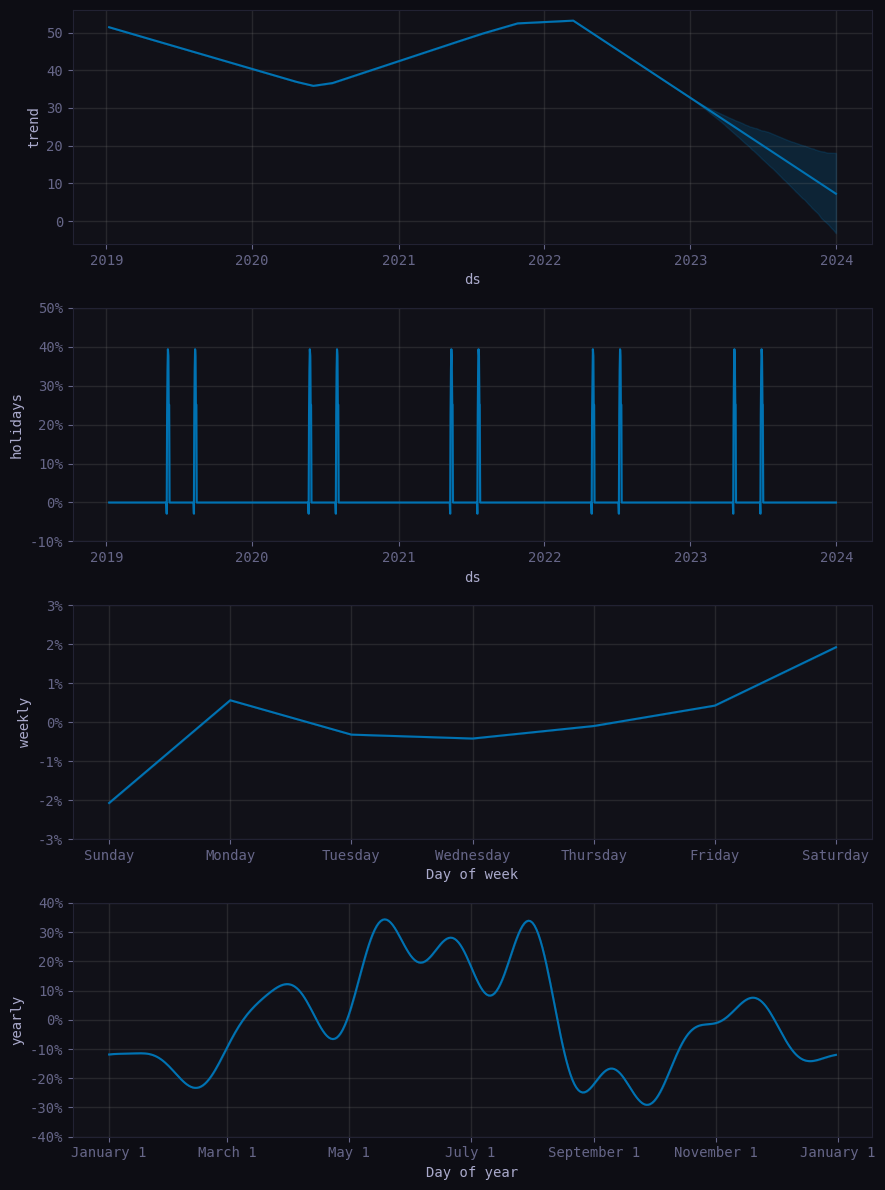

  ✓ Prophet components saved → outputs/05_prophet_components.png
  ✓ Saved → models/prophet.pkl


In [11]:
print('📈 Training Prophet (city-wide average)...')
print('  Note: Prophet operates on city-level daily average (not per-station)')

# Prophet needs city-level daily average
city_daily = df.groupby('date')[TARGET].mean().reset_index()
city_daily.columns = ['ds', 'y']
city_daily['ds'] = pd.to_datetime(city_daily['ds'])

prophet_train = city_daily[city_daily['ds'] < SPLIT_DATE]
prophet_test  = city_daily[city_daily['ds'] >= SPLIT_DATE]

# Pakistan-specific holidays as regressors
pk_holidays = pd.DataFrame({
    'holiday': 'eid_period',
    'ds': pd.to_datetime([
        '2019-06-04','2019-08-11','2020-05-24','2020-07-31',
        '2021-05-13','2021-07-20','2022-05-02','2022-07-09',
        '2023-04-21','2023-06-28',
    ]),
    'lower_window': -3,
    'upper_window': 3,
})

prophet_model = Prophet(
    seasonality_mode     = 'multiplicative',
    yearly_seasonality   = True,
    weekly_seasonality   = True,
    daily_seasonality    = False,
    holidays             = pk_holidays,
    changepoint_prior_scale = 0.1,
    holidays_prior_scale    = 10.0,
    interval_width          = 0.95,
)

prophet_model.fit(prophet_train)

future      = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='D')
forecast    = prophet_model.predict(future)
prophet_pred = forecast[forecast['ds'] >= SPLIT_DATE]['yhat'].values[:len(prophet_test)]
prophet_pred = np.clip(prophet_pred, 0, None)  # PM2.5 can't be negative

RESULTS = evaluate('Prophet', prophet_test['y'].values, prophet_pred, PALETTE[4], RESULTS)

# Plot Prophet components
fig = prophet_model.plot_components(forecast)
fig.patch.set_facecolor('#0d0d14')
plt.savefig('outputs/05_prophet_components.png', dpi=120, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('  ✓ Prophet components saved → outputs/05_prophet_components.png')

joblib.dump(prophet_model, 'models/prophet.pkl')
print('  ✓ Saved → models/prophet.pkl')

## 9. Comparative Evaluation Table

📊 COMPARATIVE EVALUATION RESULTS
                  RMSE      MAE      R²     MAPE     Bias
Random Forest  16.3027  10.6267  0.6119  22.0480  -0.1484
XGBoost        16.4128  10.9518  0.6067  23.3313   0.8326
LightGBM       16.5891  10.5924  0.5982  21.5294  -0.2108
SVR            17.5439  11.9272  0.5506  25.7490   0.5485
Prophet        40.1726  29.3644 -1.3564  51.6317 -28.2120

  Lower RMSE/MAE/MAPE = better | Higher R² = better

  ✓ Saved → outputs/05_model_comparison.csv


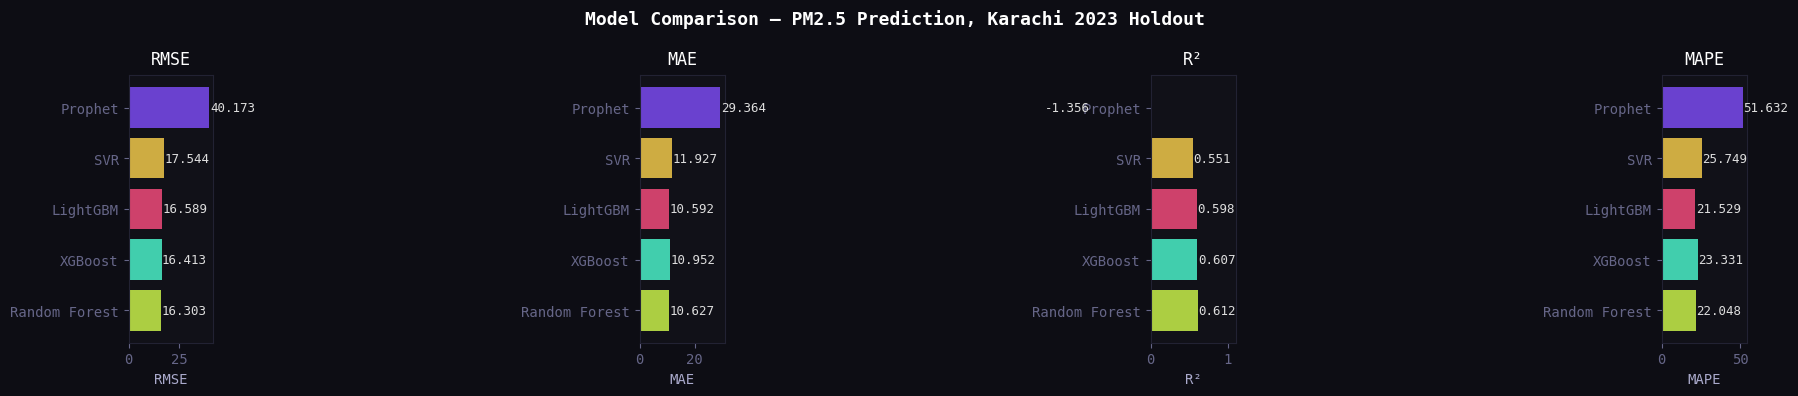

  ✓ Saved → outputs/05_model_comparison.png


In [12]:
print('📊 COMPARATIVE EVALUATION RESULTS')
print('=' * 75)

results_df = pd.DataFrame({
    model: {k: v for k, v in metrics.items() if k not in ['y_pred','color']}
    for model, metrics in RESULTS.items()
}).T.round(4)

results_df = results_df.sort_values('RMSE')
print(results_df.to_string())
print('\n  Lower RMSE/MAE/MAPE = better | Higher R² = better')

results_df.to_csv('outputs/05_model_comparison.csv')
print('\n  ✓ Saved → outputs/05_model_comparison.csv')

# Visual comparison table
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics_to_plot = ['RMSE', 'MAE', 'R²', 'MAPE']

for ax, metric in zip(axes, metrics_to_plot):
    vals   = results_df[metric].astype(float)
    colors = [RESULTS[m]['color'] for m in results_df.index]
    bars   = ax.barh(results_df.index, vals, color=colors, alpha=0.85, edgecolor='none')

    for bar, val in zip(bars, vals):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='#ddd')

    ax.set_title(metric, color='#fff', fontsize=12, pad=8)
    ax.set_xlabel(metric)
    if metric == 'R²':
        ax.set_xlim(0, 1.1)

plt.suptitle('Model Comparison — PM2.5 Prediction, Karachi 2023 Holdout',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('  ✓ Saved → outputs/05_model_comparison.png')

## 10. Prediction vs Actual Plots

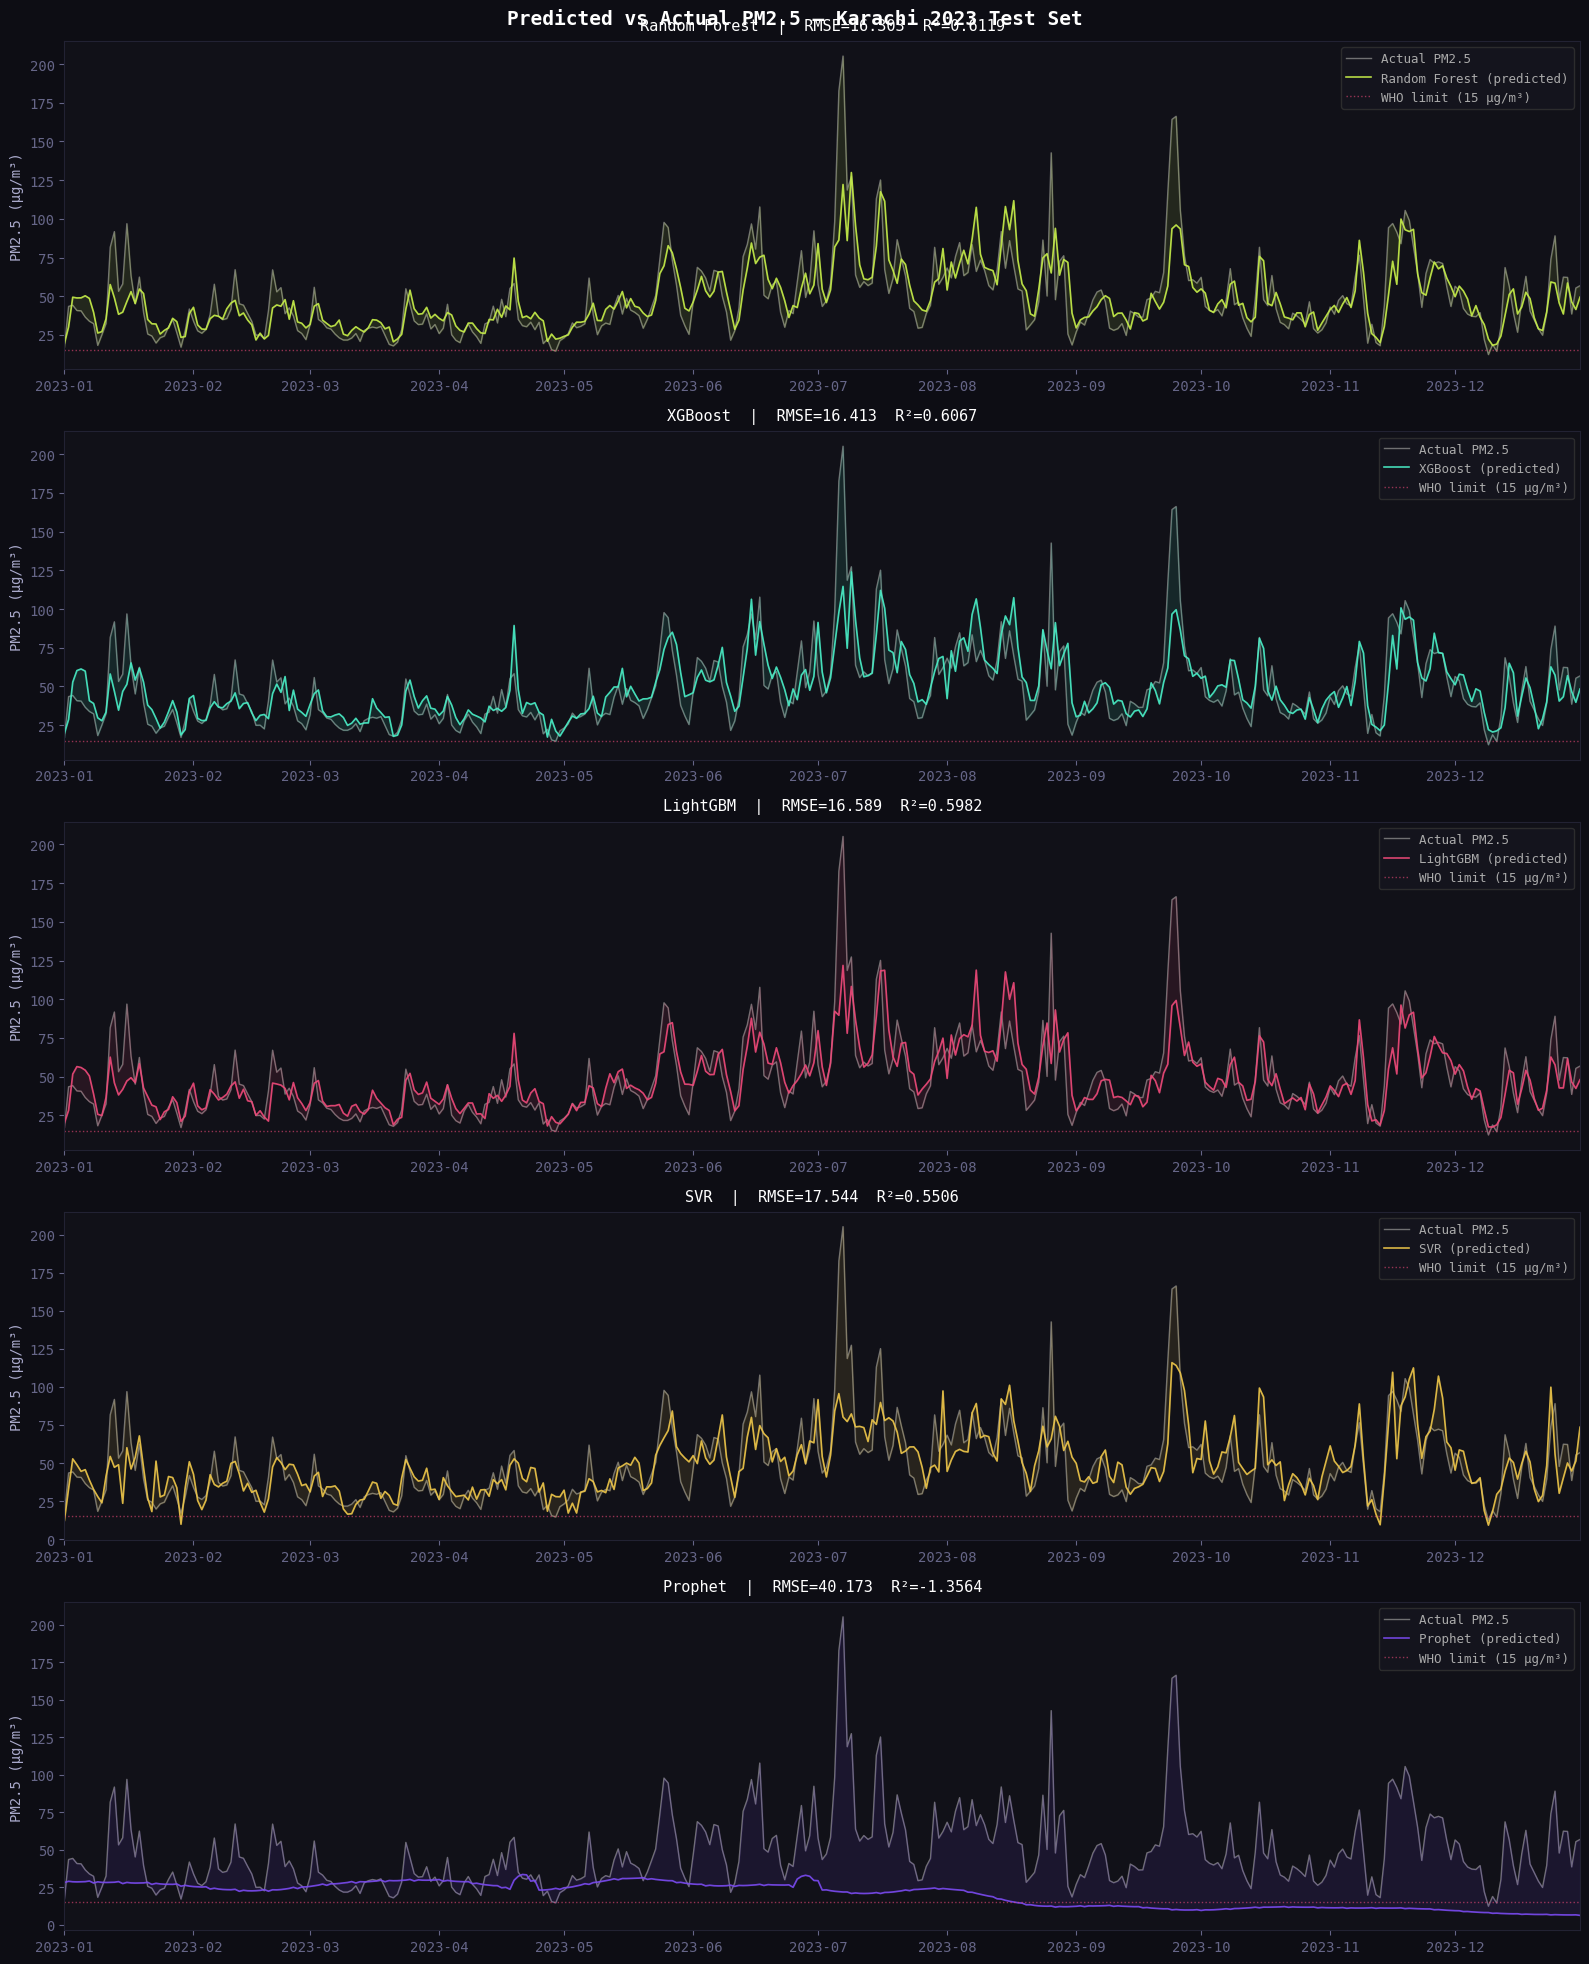

✓ Saved → outputs/05_predictions_vs_actual.png


In [13]:
fig, axes = plt.subplots(len(RESULTS), 1, figsize=(16, 4*len(RESULTS)))
if len(RESULTS) == 1: axes = [axes]

test_dates = test_df['date'].values

for ax, (model_name, res) in zip(axes, RESULTS.items()):
    y_pred = res['y_pred']
    color  = res['color']

    # For Prophet — use city-level dates
    if model_name == 'Prophet':
        dates = prophet_test['ds'].values
        actual = prophet_test['y'].values
    else:
        dates  = test_df.groupby('date')['date'].first().values
        actual = test_df.groupby('date')[TARGET].mean().values
        y_pred = test_df.copy()
        y_pred[f'pred'] = res['y_pred']
        y_pred = y_pred.groupby('date')['pred'].mean().values

    ax.plot(dates, actual, color='#888', linewidth=1.0, alpha=0.8, label='Actual PM2.5', zorder=1)
    ax.plot(dates, y_pred, color=color,  linewidth=1.2, alpha=0.9, label=f'{model_name} (predicted)', zorder=2)
    ax.fill_between(dates, actual, y_pred, alpha=0.1, color=color)

    r2   = res['R²']
    rmse = res['RMSE']
    ax.set_title(f'{model_name}  |  RMSE={rmse:.3f}  R²={r2:.4f}',
                 color='#fff', fontsize=11, pad=8)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.axhline(15, color='#f04a7a', linestyle=':', alpha=0.6, linewidth=1, label='WHO limit (15 µg/m³)')
    ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333', fontsize=9, loc='upper right')
    ax.set_xlim(dates[0], dates[-1])

plt.suptitle('Predicted vs Actual PM2.5 — Karachi 2023 Test Set',
             color='#fff', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_predictions_vs_actual.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('✓ Saved → outputs/05_predictions_vs_actual.png')

## 11. SHAP Feature Importance (XGBoost + RF)

🔍 Computing SHAP values (XGBoost)...
  This may take 2-3 minutes...


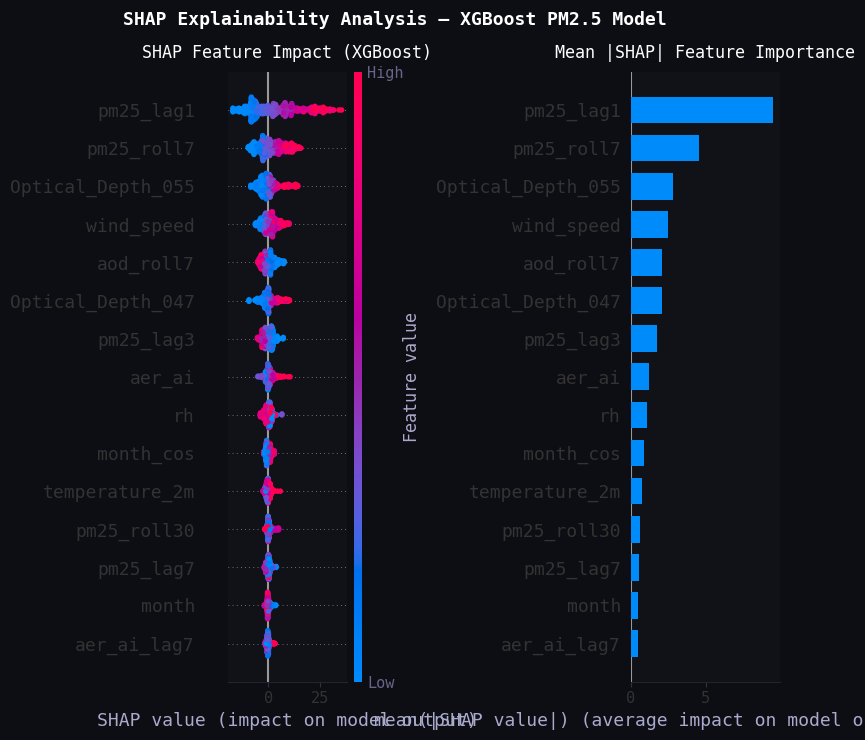

✓ Saved → outputs/05_shap_analysis.png

Top 10 features by mean |SHAP|:
  pm25_lag1                 ████████████████████ 9.4957
  pm25_roll7                █████████ 4.5423
  Optical_Depth_055         █████ 2.8125
  wind_speed                █████ 2.4798
  aod_roll7                 ████ 2.0911
  Optical_Depth_047         ████ 2.0639
  pm25_lag3                 ███ 1.7514
  aer_ai                    ██ 1.2254
  rh                        ██ 1.0905
  month_cos                 █ 0.8886


In [14]:
print('🔍 Computing SHAP values (XGBoost)...')
print('  This may take 2-3 minutes...')

# Use a sample for speed (SHAP on full dataset is slow)
sample_idx  = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
X_test_sample = X_test[sample_idx]

explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SHAP summary — beeswarm
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=FEATURE_COLS,
    max_display=15, show=False,
    plot_type='dot'
)
axes[0].set_title('SHAP Feature Impact (XGBoost)', color='#fff', pad=10)

# SHAP bar — mean absolute
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=FEATURE_COLS,
    max_display=15, show=False,
    plot_type='bar'
)
axes[1].set_title('Mean |SHAP| Feature Importance', color='#fff', pad=10)

plt.suptitle('SHAP Explainability Analysis — XGBoost PM2.5 Model',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_shap_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('✓ Saved → outputs/05_shap_analysis.png')

# Top features
mean_shap = np.abs(shap_values).mean(0)
top_features = sorted(zip(FEATURE_COLS, mean_shap), key=lambda x: -x[1])[:10]
print('\nTop 10 features by mean |SHAP|:')
for feat, val in top_features:
    bar = '█' * int(val/max(mean_shap)*20)
    print(f'  {feat:<25} {bar} {val:.4f}')

## 12. Residual Analysis

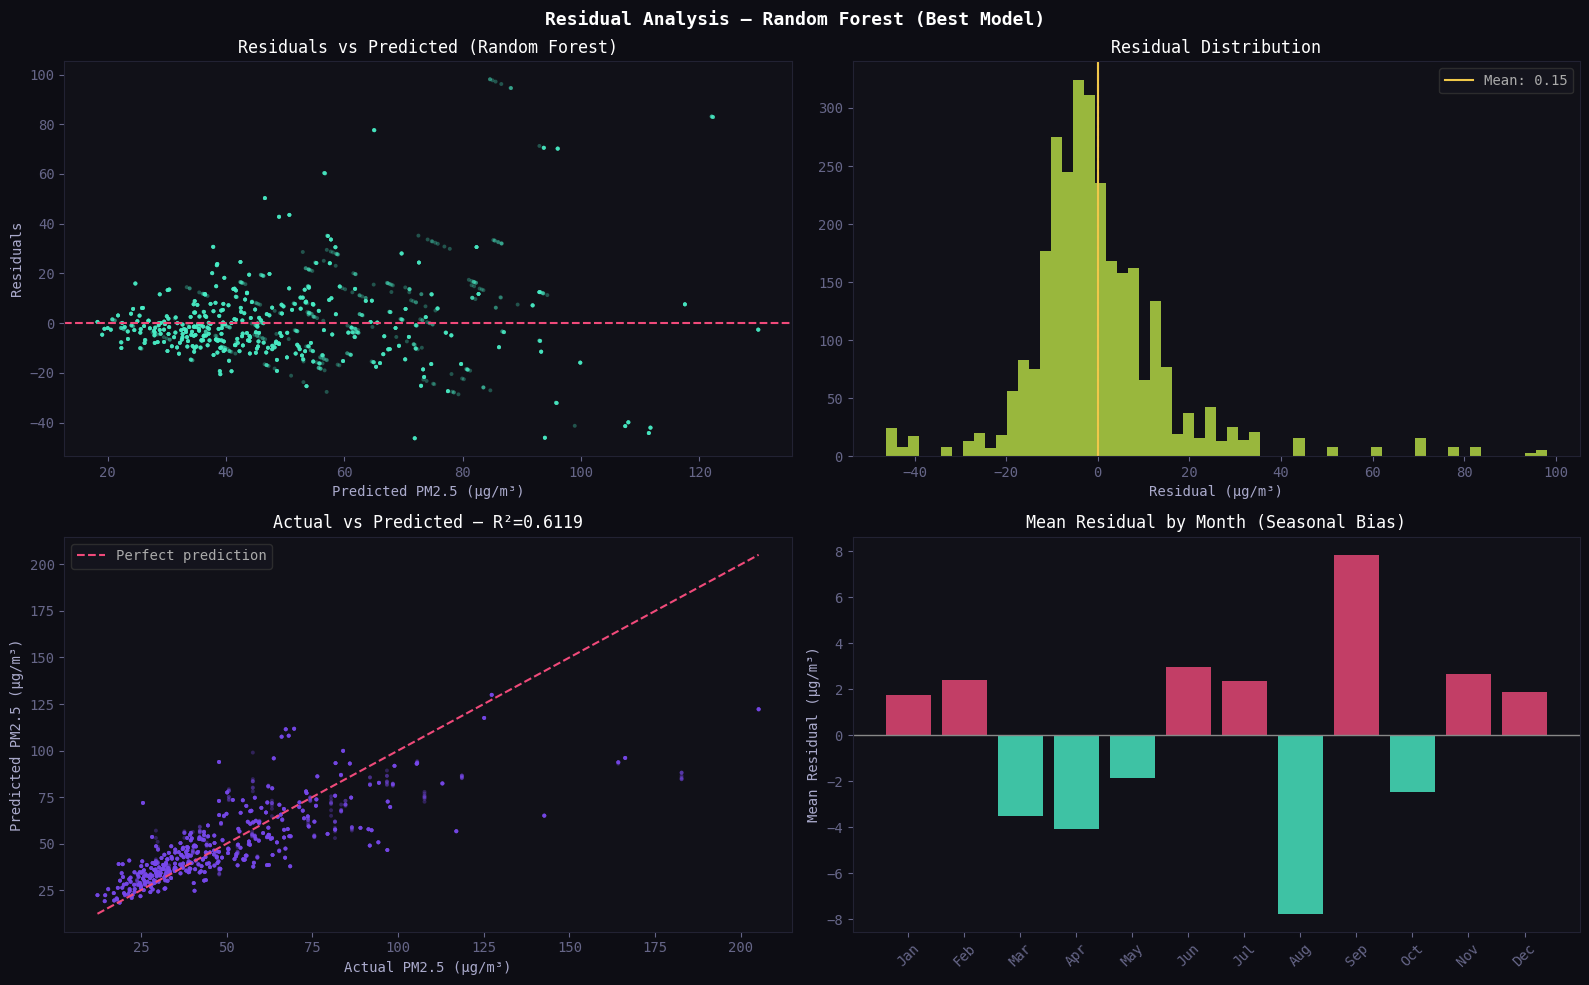

✓ Saved → outputs/05_residual_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Best model = lowest RMSE
best_model_name = results_df.index[0]
best_pred       = RESULTS[best_model_name]['y_pred']
residuals       = y_test - best_pred

# 1. Residuals vs Predicted
ax = axes[0,0]
ax.scatter(best_pred, residuals, alpha=0.3, color='#4af0c8', s=8, edgecolors='none')
ax.axhline(0, color='#f04a7a', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted PM2.5 (µg/m³)')
ax.set_ylabel('Residuals')
ax.set_title(f'Residuals vs Predicted ({best_model_name})', color='#fff')

# 2. Residual distribution
ax = axes[0,1]
ax.hist(residuals, bins=60, color='#c8f04a', alpha=0.75, edgecolor='none')
ax.axvline(0, color='#f04a7a', linewidth=1.5, linestyle='--')
ax.axvline(residuals.mean(), color='#f0c84a', linewidth=1.5,
           label=f'Mean: {residuals.mean():.2f}')
ax.set_title('Residual Distribution', color='#fff')
ax.set_xlabel('Residual (µg/m³)')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

# 3. Actual vs Predicted scatter
ax = axes[1,0]
ax.scatter(y_test, best_pred, alpha=0.3, color='#7a4af0', s=8, edgecolors='none')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims, lims, color='#f04a7a', linewidth=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Actual vs Predicted — R²={RESULTS[best_model_name]["R²"]:.4f}', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

# 4. Error by month (seasonal bias check)
ax = axes[1,1]
test_df_copy = test_df.copy()
test_df_copy['residual'] = residuals
test_df_copy['month']    = test_df_copy['date'].dt.month
monthly_err = test_df_copy.groupby('month')['residual'].mean()
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(range(1,13), monthly_err.values,
       color=['#f04a7a' if v > 0 else '#4af0c8' for v in monthly_err.values],
       alpha=0.8, edgecolor='none')
ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTHS, rotation=45)
ax.axhline(0, color='#888', linewidth=1)
ax.set_title('Mean Residual by Month (Seasonal Bias)', color='#fff')
ax.set_ylabel('Mean Residual (µg/m³)')

plt.suptitle(f'Residual Analysis — {best_model_name} (Best Model)',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_residual_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14', edgecolor='none')
plt.show()
print('✓ Saved → outputs/05_residual_analysis.png')

## 13. Final Summary

In [16]:
print('=' * 65)
print('✅ NOTEBOOK 05 COMPLETE — MODEL TRAINING & EVALUATION')
print('=' * 65)
print()
print('RESULTS SUMMARY (sorted by RMSE):')
print(results_df[['RMSE','MAE','R²','MAPE']].to_string())
print()
print(f'  🏆 Best model : {results_df.index[0]}')
print(f'     RMSE       : {results_df["RMSE"].iloc[0]:.4f} µg/m³')
print(f'     R²         : {results_df["R²"].iloc[0]:.4f}')
print()
print('Saved models:')
for f in ['models/random_forest.pkl','models/xgboost.pkl',
          'models/lightgbm.pkl','models/svr.pkl','models/prophet.pkl']:
    exists = '✓' if Path(f).exists() else '✗'
    print(f'  {exists} {f}')
print()
print('Saved outputs:')
for f in ['outputs/05_model_comparison.csv',
          'outputs/05_model_comparison.png',
          'outputs/05_predictions_vs_actual.png',
          'outputs/05_shap_analysis.png',
          'outputs/05_residual_analysis.png',
          'outputs/05_prophet_components.png']:
    exists = '✓' if Path(f).exists() else '✗'
    print(f'  {exists} {f}')
print()
print('NEXT: Run 06_spatial_analysis.ipynb')
print('  → Moran\'s I spatial autocorrelation')
print('  → Karachi PM2.5 heatmaps')
print('  → Station-level hotspot analysis')
print()
print('THEN: Run 07_lstm_digital_twin.ipynb')
print('  → LSTM time series forecasting (CUDA)')
print('  → Scenario simulation (digital twin layer)')

✅ NOTEBOOK 05 COMPLETE — MODEL TRAINING & EVALUATION

RESULTS SUMMARY (sorted by RMSE):
                  RMSE      MAE      R²     MAPE
Random Forest  16.3027  10.6267  0.6119  22.0480
XGBoost        16.4128  10.9518  0.6067  23.3313
LightGBM       16.5891  10.5924  0.5982  21.5294
SVR            17.5439  11.9272  0.5506  25.7490
Prophet        40.1726  29.3644 -1.3564  51.6317

  🏆 Best model : Random Forest
     RMSE       : 16.3027 µg/m³
     R²         : 0.6119

Saved models:
  ✓ models/random_forest.pkl
  ✓ models/xgboost.pkl
  ✓ models/lightgbm.pkl
  ✓ models/svr.pkl
  ✓ models/prophet.pkl

Saved outputs:
  ✓ outputs/05_model_comparison.csv
  ✓ outputs/05_model_comparison.png
  ✓ outputs/05_predictions_vs_actual.png
  ✓ outputs/05_shap_analysis.png
  ✓ outputs/05_residual_analysis.png
  ✓ outputs/05_prophet_components.png

NEXT: Run 06_spatial_analysis.ipynb
  → Moran's I spatial autocorrelation
  → Karachi PM2.5 heatmaps
  → Station-level hotspot analysis

THEN: Run 07_lstm_dig